# Reading provenance directly
The processed RO-Crates contain a new directory with provenance data.
The file contain a provenance directory with the PROV-O graph (JSON-LD and Turtle) and one file for each dataset, containing dataset metadata including interoperability and discovery metadata.

```
exp_crate/
|-- datasets/
|   |-- ds_001.xxx
|   `-- ...
|-- provenance/
|   |-- galaxy_run_prov.jsonld
|   |-- galaxy_run_prov.ttl
|   |-- dataset_ds_001.xxx.jsonld
|   `-- ...
|-- workflow/
|--ro-crate-metadata.json
...
```
We can extract and use provenance data directly.

## Reading the RO-Crate

The code below shows how to get the RO-Crate provenance metadata and shows the PROVO graph resulting from it.

C:\Users\scman1\AppData\Roaming\Python\Python39\site-packages\rocrate\vocabs.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


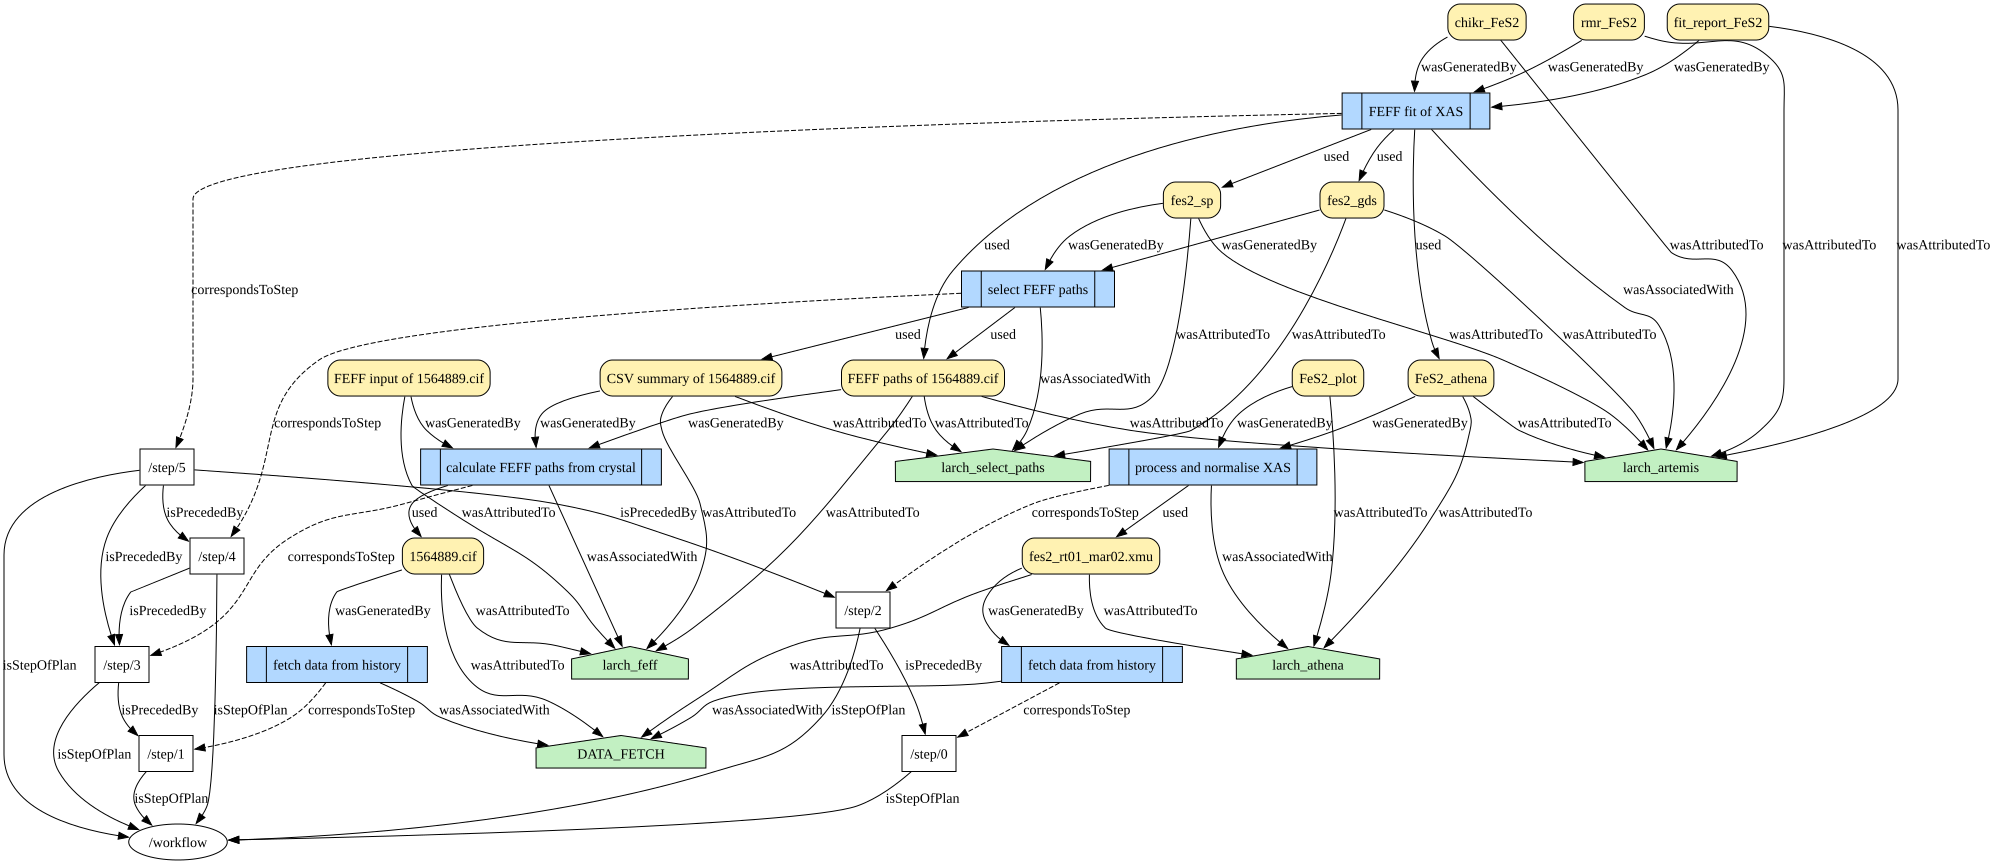

In [1]:
# RO-Crate access
from rocrate.rocrate import ROCrate
# Directory and file management
from pathlib import Path

# defined functions to get data from RO-Crate
from read_provenance import *

# "FeS2-Analysis.rocrate.prov.zip" FeS2 example modified
# "Paper_1_Pt3Sn.rocrate.prov.zip" paper 1 modified
file_name = "FeS2-Analysis.rocrate.prov.zip"

file_path = Path("./result_roc", file_name)

# get the PROV-O graph from the RO-Crate
roc_prov = get_roc_provenance(file_path)

#plan_dot = draw_prov_only(roc_prov)
#display(plan_dot)

#plan_dot = draw_pplan_only(roc_prov)
#display(plan_dot)

fullprov_dot = draw_prov_full(roc_prov)
display(fullprov_dot)

## Accessing Dataset Metadata

Dataset metadata is included in the provenance graph and in individual json files. 

The provenance graph includes basic provenance data and some dataset metadata. 

The individual metadata files includes additional information which caracterise each dataset (e.g. file type, format, experiment data)



### Datasets list
the get_datasets_prov function returns a data frame with a summary of all the datasets and their provenance history. 

The first three columns indicate the step, tool and activity that generated the data. 

The fourh column shows the name of the dataset.
The last column lists the inputs used to generate the dataset.

In [2]:
#get datasets provenance from the roc graph
datasets_provenance = get_datasets_prov(roc_prov)
display(HTML(datasets_provenance.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
1,/step/1,fetch data from history,DATA_FETCH,1564889.cif,None
2,/step/2,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
3,/step/2,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu
4,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
5,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
6,/step/3,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
7,/step/4,select FEFF paths,larch_select_paths,fes2_sp,"FEFF paths of 1564889.cif, CSV summary of 1564889.cif"
8,/step/4,select FEFF paths,larch_select_paths,fes2_gds,"FEFF paths of 1564889.cif, CSV summary of 1564889.cif"
9,/step/5,FEFF fit of XAS,larch_artemis,chikr_FeS2,"FEFF paths of 1564889.cif, fes2_gds, fes2_sp, FeS2_athena"


### Provenance File and generation of json files
The show_datasets function just extracts all the datasets info from the provenance graph and shows them all as tables.
The last two parameters indicate the output pat for the individual json-ld files (output_path) and if they should be generated (show_only)
In the example the data is only shown, no files are generated.

In [3]:
ds_jsons = show_datasets(roc_prov, file_path, output_path = "",  show_only = True)

,Property,Value
0,schema:id,datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
2,rdf:type,prov:Entity
3,rdf:type,schema:MediaObject
4,prov:wasGeneratedBy,fetch data from history
5,prov:wasAttributedTo,larch_athena
6,prov:wasAttributedTo,DATA_FETCH
7,dcterms:description,uploaded txt file
8,dcterms:format,text/plain
9,skos:prefLabel,fes2_rt01_mar02.xmu


,Property,Value
0,rdf:type,schema:MediaObject
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
2,rdf:type,prov:Entity
3,dcterms:description,"Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.You can still use this dataset in tools and workflows.For full metadata, ask your admin to install the 'ase' Python package."
4,dcterms:format,chemical/x-cif
5,prov:wasAttributedTo,larch_feff
6,prov:wasAttributedTo,DATA_FETCH
7,skos:prefLabel,1564889.cif
8,schema:id,datasets/1564889.cif_df02c7af9dfe5b62.cif
9,prov:wasGeneratedBy,fetch data from history


,Property,Value
0,prov:wasAttributedTo,larch_artemis
1,prov:wasAttributedTo,larch_athena
2,rdf:type,schema:MediaObject
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,rdf:type,prov:Entity
5,prov:wasGeneratedBy,process and normalise XAS
6,dcterms:format,application/vnd.demeter.athena
7,schema:id,datasets/FeS2_athena_d49ffa4044c67d15.prj
8,skos:prefLabel,FeS2_athena
9,dcterms:description,atsym: Febkg_e0: 7117.0edge: Knpts: 352xmax: 7963.5xmin: 6911.8


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
2,rdf:type,prov:Entity
3,rdf:type,schema:MediaObject
4,dcterms:format,image/png
5,skos:prefLabel,FeS2_plot
6,prov:wasGeneratedBy,process and normalise XAS
7,schema:id,datasets/FeS2_plot_6c2ea4582a260280.png
8,prov:wasAttributedTo,larch_athena
9,dcterms:description,"Attempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.datRead columns: ['energy', 'xmu', 'i0']'energy' present in column headersRenaming columns to: ['energy', 'mu', 'i0']Cannot load group.athena_params.bkg from gro"


,Property,Value
0,prov:wasGeneratedBy,calculate FEFF paths from crystal
1,schema:id,datasets/FEFF_input_of_1564889.cif_409c0d24534294d8.inp
2,dcterms:description,Formula: FeS2SpaceGroup: Pnnm# sites: 6
3,rdf:type,prov:Entity
4,rdf:type,schema:MediaObject
5,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
6,dcterms:format,chemical/x-feff-input
7,prov:wasAttributedTo,larch_feff
8,skos:prefLabel,FEFF input of 1564889.cif
9,dcterms:subject,<http://purl.org/pan-science/PaNET/PaNET01082>


...

,Property,Value
0,prov:wasGeneratedBy,select FEFF paths
1,prov:wasAttributedTo,larch_artemis
2,prov:wasAttributedTo,larch_select_paths
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,rdf:type,prov:Entity
6,dcterms:description,
7,schema:id,datasets/fes2_sp_75738551921d866c.sp
8,skos:prefLabel,fes2_sp
9,dcterms:format,text/csv


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,prov:Entity
2,rdf:type,schema:MediaObject
3,skos:prefLabel,fes2_gds
4,dcterms:format,text/csv
5,prov:wasGeneratedBy,select FEFF paths
6,prov:wasAttributedTo,larch_artemis
7,prov:wasAttributedTo,larch_select_paths
8,schema:id,datasets/fes2_gds_547228271cdb66e2.gds
9,dcterms:description,


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,prov:Entity
2,rdf:type,schema:MediaObject
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
4,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
5,dcterms:format,image/png
6,schema:id,datasets/chikr_FeS2_c3e4da2bb600d6e3.png
7,prov:wasAttributedTo,larch_artemis
8,prov:wasGeneratedBy,FEFF fit of XAS
9,skos:prefLabel,chikr_FeS2


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,prov:Entity
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
3,rdf:type,schema:MediaObject
4,dcterms:format,image/png
5,schema:id,datasets/rmr_FeS2_fb5bc774c9b03fce.png
6,prov:wasAttributedTo,larch_artemis
7,skos:prefLabel,rmr_FeS2
8,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
9,prov:wasGeneratedBy,FEFF fit of XAS


,Property,Value
0,prov:wasAttributedTo,larch_artemis
1,schema:id,datasets/fit_report_FeS2_a9305118c6acc078.feffit
2,skos:prefLabel,fit_report_FeS2
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,rdf:type,prov:Entity
5,rdf:type,schema:MediaObject
6,dcterms:format,text/plain
7,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
8,prov:wasGeneratedBy,FEFF fit of XAS
9,dcterms:subject,<http://purl.org/pan-science/PaNET/PaNET01198>


### Accessing the individual datasets files

The code cell below:
- reads the RO-Crate and gets all dataset provenance files in a list
- loads the first provenance file
- shows its contents as JSON

In [4]:
crate = ROCrate(file_path)
data_entities = []
for e in crate.get_entities():
    if "provenance/data" in e.id:
        #print(e.id, e.type)
        data_entities.append(e.id)
        
print (f"There are {len(data_entities)} datasets in {file_name}\n")
f = get_file_from_rocratezip(file_path, data_entities[0])
ds_details = json.load(f)

print(json.dumps(ds_details, indent=2))

There are 12 datasets in FeS2-Analysis.rocrate.prov.zip

{
  "@context": {
    "cdif4xas": "https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#",
    "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
    "dcterms": "http://purl.org/dc/terms/",
    "ex": "http://example.org#",
    "panet": "http://purl.org/pan-science/PaNET/",
    "prov": "http://www.w3.org/ns/prov#",
    "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
    "schema": "https://schema.org/",
    "skos": "http://www.w3.org/2004/02/skos/core#",
    "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
  },
  "@id": "dataset_df0bac1ee137448a.jsonld",
  "@type": [
    "prov:Entity",
    "cdifprov:Dataset",
    "schema:MediaObject",
    "schema:CreativeWork"
  ],
  "cdif4xas:beamline": "GSECARS 13BM, vert slits = 2mm (at 45m)",
  "cdif4xas:e0": "7117.0",
  "cdif4xas:edge": "K",
  "cdif4xas:element": "Fe",
  "cdif4xas:sample_formula": "FeS2",
  "cdif4xas:sample_name": "FeS2 

### Dataset as a graph

The code below ushes the same data and displays it as a graph

In [5]:
small_graph = Graph()
#small_graph = get_panet_entities()
small_graph.parse("resources/panent_fragment.ttl")
small_graph.parse("resources/sweet-pl.ttl") 

small_graph.parse(
            data=json.dumps(ds_details),
            format="json-ld",publicID="/" )

small_graph = fix_graph_root(small_graph)

nx_graph = rdflib_to_networkx_graph(small_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 56 nodes and 46 edges loaded successfully
nx.html


## Working with the datasets metadata
Having access to the provenance and dataset context metadata allows rapid access to the data.
For instance the code below shows how to summarise the Types and Formats of the dataset files in the RO-Crate.

### File inventory
The quickest data we can get from provenance is a data inventory. The code below summarises types and formats from the graph.

In [6]:
from collections import Counter
from rdflib import RDF, Namespace

PROV = Namespace("http://www.w3.org/ns/prov#")
entities = set(roc_prov.subjects(RDF.type, PROV.Entity))

types = Counter()
formats = Counter()
subjects = Counter()
for e in entities:
    # entity types
    for t in roc_prov.objects(e, RDF.type):
        if t != PROV.Entity:
            types[str(t).split("/")[-1]] += 1

    # file formats
    for f in roc_prov.objects(e, DCTERMS.format):
        formats[str(f)] += 1

print("Total datasets:", len(entities))

print("\nTypes")
for k, v in types.most_common():
    print(f"{k}: {v}")

print("\nFormats")
for k, v in formats.most_common():
    print(f"{k}: {v}")
    

Total datasets: 12

Types
MediaObject: 12
CDIF-PROV#Dataset: 12
CDIF-PROV#DataProduct: 3

Formats
image/png: 3
text/csv: 3
text/plain: 2
chemical/x-cif: 1
application/zip: 1
chemical/x-feff-input: 1
application/vnd.demeter.athena: 1


### Context metadata

Using the datasets individual metadata files we can get more insights about the contents of the RO-Crate.

For instance, the code below shows how to recover and summarise the datasets metadata using terms relevant to the XAS context.

In [7]:
# sumarisig datasets 2
# look up graphs
panet_graph = Graph()
sweet_graph = Graph()
panet_graph.parse("resources/panent_fragment.ttl")
sweet_graph.parse("resources/sweet-pl.ttl") 


def first_object(graph, predicate, default=""):
    return next(graph.objects(None, predicate), default)

FIELD_MAP = {
    "dataset": SKOS.prefLabel,
    "file_type": DCTERMS.format,
    #"location": SCHEMA.id,
    "element": CDIF4XAS.element,
    "edge": CDIF4XAS.edge,
    "e0": CDIF4XAS.e0,
}

ds_data = {}

for an_ent in data_entities:
    g = Graph()
    # load dataset data into a graph
    g.parse(
        data=json.dumps(get_roc_json_part(file_path, an_ent)),
        format="json-ld",
        publicID="/"
    )
    # get the data from graph the triples
    ent_data = {
        key: first_object(g, pred)
        for key, pred in FIELD_MAP.items()
    }
    # Get PANET and SWEET data as readable labels
    for subject in g.objects(None, DCTERMS.subject):
        target_graph, pred, key = (
            (panet_graph, SKOS.altLabel, "data_type")
            if str(PANET) in str(subject)
            else (sweet_graph, SKOS.prefLabel, "proc_level")
        )
        ent_data[key] = next(
            target_graph.objects(subject, pred),
            ""
        )

    ds_data[an_ent] = ent_data

df = pd.DataFrame.from_dict(ds_data, orient="index")

summary = {
    "element": df["element"].value_counts(),
    "file_type": df["file_type"].value_counts(),
    "proc_level": df["proc_level"].value_counts(),
    "data_type": df["data_type"].value_counts(),
}

for category, counts in summary.items():
    print(f"\n{category.upper()}")
    print(counts)

display(HTML(df.to_html().replace("\\n","<br>")))


ELEMENT
      7
Fe    5
Name: element, dtype: int64

FILE_TYPE
image/png                         3
text/csv                          3
text/plain                        2
chemical/x-cif                    1
application/vnd.demeter.athena    1
chemical/x-feff-input             1
application/zip                   1
Name: file_type, dtype: int64

PROC_LEVEL
Derived      7
Product      3
Raw          1
Processed    1
Name: proc_level, dtype: int64

DATA_TYPE
obtain crystal structure    6
EXAFS                       3
NEXAFS                      2
XAS                         1
Name: data_type, dtype: int64


,dataset,file_type,element,edge,e0,data_type,proc_level
provenance/dataset_df0bac1ee137448a.jsonld,fes2_rt01_mar02.xmu,text/plain,Fe,K,7117.0,XAS,Raw
provenance/dataset_df02c7af9dfe5b62.jsonld,1564889.cif,chemical/x-cif,,,,obtain crystal structure,Derived
provenance/dataset_d49ffa4044c67d15.jsonld,FeS2_athena,application/vnd.demeter.athena,Fe,K,7117.0,NEXAFS,Processed
provenance/dataset_6c2ea4582a260280.jsonld,FeS2_plot,image/png,,K,,NEXAFS,Product
provenance/dataset_409c0d24534294d8.jsonld,FEFF input of 1564889.cif,chemical/x-feff-input,,,,obtain crystal structure,Derived
provenance/dataset_a38f4b5b93cd4e1a.jsonld,CSV summary of 1564889.cif,text/csv,,,,obtain crystal structure,Derived
provenance/dataset_a011be860e2a8b79.jsonld,FEFF paths of 1564889.cif,application/zip,,,,obtain crystal structure,Derived
provenance/dataset_547228271cdb66e2.jsonld,fes2_gds,text/csv,,,,obtain crystal structure,Derived
provenance/dataset_75738551921d866c.jsonld,fes2_sp,text/csv,,,,obtain crystal structure,Derived
provenance/dataset_c3e4da2bb600d6e3.jsonld,chikr_FeS2,image/png,Fe,K,7117.0,EXAFS,Product


In [8]:
summary = (
    df.groupby(["element", "data_type", "proc_level"])
      .size()
)
summary

element  data_type                 proc_level
         NEXAFS                    Product       1
         obtain crystal structure  Derived       6
Fe       EXAFS                     Derived       1
                                   Product       2
         NEXAFS                    Processed     1
         XAS                       Raw           1
dtype: int64